# Resource Demand Forecasting Model
Predict facility-level resource needs for treatment planning and allocation optimization.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

## Load Data
Load the raw patient treatment dataset and check basic structure.
Dataset contains individual patient records with demographics, substance use patterns, and treatment info

In [6]:
df = pd.read_csv("1_datasets/processed/teds_ml_ready.csv")

## Initial Data Quality Checks
Understand data structure, missing values, and data types.
Missing values inform our imputation strategy (high/medium/low missingness)


In [7]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(10))

recent_arrests           94.032413
tertiary_substance       85.553990
pregnant                 69.567723
secondary_substance      58.873820
health_insurance         54.032610
payment_source           53.369380
marital_status           29.164373
self_help_attendance     27.269652
age_first_use_primary    25.342517
frequency_primary        23.216653
dtype: float64


## Data Cleaning & Type Conversion
Handle missing values and convert problematic columns from object to numeric.
Numeric cols to fill with median | Categorical cols to fill with mode.
This prepares clean data for feature engineering.

In [8]:
df_clean = df.copy()

# Handle missing values broadly before specific logic
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if col in numeric_cols:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            mode_val = (
                df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else "Unknown"
            )
            df_clean[col].fillna(mode_val, inplace=True)

# Convert problematic numeric columns
potential_numeric = df_clean.select_dtypes(include=["object"]).columns
for col in potential_numeric:
    converted = pd.to_numeric(df_clean[col], errors="coerce")
    if converted.isnull().sum() < df_clean[col].isnull().sum() * 2:
        df_clean[col] = converted.fillna(0)

## Pre-Aggregation One-Hot Encoding
Convert categorical demographics to binary columns BEFORE aggregating.
This preserves distributions (e.g., % Female) instead of losing info via mode().
When aggregated by mean, these become percentages for each facility.

In [9]:
cols_to_encode = ["age_group", "race", "sex", "ethnicity", "education_level"]
existing_cols = [c for c in cols_to_encode if c in df_clean.columns]
df_encoded = pd.get_dummies(
    df_clean, columns=existing_cols, prefix=existing_cols, dtype=float
)

## Aggregate by State & Service Type
Group individual patient records by (state, service_type).
Target: Count of patients = total_admissions.
Features: Mean of binary indicators = prevalence rates for that facility type.
This is where we CREATE the training dataset.

In [10]:
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
if "patient_id" in numeric_cols:
    numeric_cols.remove("patient_id")

agg_dict = {col: "mean" for col in numeric_cols}
agg_dict["patient_id"] = "count"

df_grouped = df_encoded.groupby(["state", "service_type"], as_index=False).agg(agg_dict)
df_grouped.rename(columns={"patient_id": "total_admissions"}, inplace=True)

## Feature Engineering - Complexity Score
Create a composite metric: complexity_score.
Weights reflect severity of each condition (chronic=2.0 is most serious).
Since we aggregated by mean, values are 0.0-1.0 (prevalence rates).
Score reflects average complexity of facility's patient population.

In [ ]:
# Complexity Score
df_grouped["complexity_score"] = (
    df_grouped.get("is_polysubstance", 0) * 1.5
    + df_grouped.get("is_chronic_treatment", 0) * 2.0
    + df_grouped.get("has_mental_health_disorder", 0) * 1.8
    + df_grouped.get("is_homeless", 0) * 1.5
    + df_grouped.get("is_injection_user", 0) * 2.0
)
# One-hot encode remaining categorical features
df_final = pd.get_dummies(
    df_grouped, columns=["state", "service_type"], drop_first=True
)

## Train-Test Split
Split before imputation/scaling to prevent leakage.
Imputer & scaler will fit only on training data.
This ensures test data statistics don't influence preprocessing.

In [12]:
# Separate X and y
y_raw = df_final["total_admissions"]
X = df_final.drop(columns=["total_admissions"])

# Log Transform Target (Handling skew)
y_log = np.log1p(y_raw)

# Remove Leakage
leakage_cols = [
    c for c in X.columns if "admission" in c.lower() or "count" in c.lower()
]
X = X.drop(columns=leakage_cols)

# Split Data
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
y_test_raw = np.expm1(y_test_log)  # Keep raw version for metrics

print(f"Train samples: {len(X_train)}")
print(f"Test samples:  {len(X_test)}")
print(f"Target Skew (Raw): {y_raw.skew():.2f}")
print(f"Target Skew (Log): {y_log.skew():.2f}")

Train samples: 236
Test samples:  59
Target Skew (Raw): 7.29
Target Skew (Log): -0.40


## Imputation & Scaling (Fit on Train Only)
Imputer & scaler learn statistics ONLY from training data.
Test data is transformed using train statistics (simulates true production scenario).
This gives honest estimate of how model performs on unseen data.

In [13]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

# Fit on Train, Transform Train & Test
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed), columns=X_train.columns
)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns)

## Train Multiple Models
Compare 3 different algorithms: Ridge, Random Forest, Gradient Boosting
Evaluate on TEST data (holds out 20% for final assessment)
Use CROSS-VALIDATION on TRAIN data (5-fold, more robust than single split)

In [38]:
models = {
    "Ridge": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=2,
        min_samples_split=5,
        max_features="sqrt",
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=2,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
    ),
}

results = []

for name, model in models.items():
    # Fit on Log Y
    model.fit(X_train_scaled, y_train_log)

    # Predict Log Y
    preds_test_log = model.predict(X_test_scaled)

    # Convert to Real Y
    preds_test_raw = np.expm1(preds_test_log)

    # Calculate Metrics
    r2 = r2_score(y_test_raw, preds_test_raw)
    mae = mean_absolute_error(y_test_raw, preds_test_raw)

    results.append({"Model": name, "R2": r2, "MAE": mae, "Object": model})
    print(f"{name}: R²={r2:.4f}, MAE={mae:.0f}")

# Select Best Model
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
best_model_info = results_df.iloc[0]
best_model = best_model_info["Object"]

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train_log, cv=cv, scoring="r2")
print(f"{name} CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Ridge: R²=0.5087, MAE=3529
Random Forest: R²=0.2031, MAE=3866
Gradient Boosting: R²=0.6230, MAE=2985
Gradient Boosting CV R²: 0.7990 (+/- 0.0485)


## Retrain Best Model on Full Data (Production)
retrain it on ALL data (no more train/test split).
This captures all available signal for production predictions.
Use full-data fitted imputer/scaler, not the train-only ones.

In [ ]:
# Process Full Dataset
imputer_prod = SimpleImputer(strategy="median")
scaler_prod = StandardScaler()
X_full_imputed = pd.DataFrame(imputer_prod.fit_transform(X), columns=X.columns)
X_full_scaled = pd.DataFrame(
    scaler_prod.fit_transform(X_full_imputed), columns=X.columns
)

# Retrain Best Model on Full Log Data
y_full_log = np.log1p(y_raw)
best_model_prod = clone(best_model)
best_model_prod.fit(X_full_scaled, y_full_log)

Bias Correction Factor: 1.0014


## Generate Predictions
Use production model to predict admissions for all facilities.
Clip negative predictions to 0 (admissions cannot be negative).
Calculate the Bias Correction.

In [ ]:
# Calculate Bias Correction
train_preds_log = best_model_prod.predict(X_full_scaled)
train_preds_raw = np.maximum(np.expm1(train_preds_log), 0)

actual_total = y_raw.sum()
predicted_total = train_preds_raw.sum()
correction_factor = actual_total / predicted_total

print(f"Bias Correction Factor: {correction_factor:.4f}")

Bias Correction Factor: 1.0014


## Generate The Final Values
Generate final predictions by converting the model’s log-scaled outputs back to the original scale using `expm1`, then applying a correction factor and clipping negatives to zero. The resulting values are stored in `df_grouped["predicted_admissions"]`.


In [28]:
# Generate final values
log_preds = best_model_prod.predict(X_full_scaled)
raw_preds = np.expm1(log_preds)
final_preds = raw_preds * correction_factor  # Apply correction
final_preds = np.maximum(final_preds, 0)

df_grouped["predicted_admissions"] = final_preds

## Calculate Resource Requirements
Convert predicted admissions into actionable resource recommendations
Beds: Assume 12 patients per bed (standard occupancy rate)
Staff: Assume 50 patients per staff member, adjusted by facility complexity
High-demand flag: Identifies facilities above median volume for priority

In [29]:
# Bed Logic: 1 bed per 12 annual admissions
df_grouped["recommended_beds"] = np.ceil(df_grouped["predicted_admissions"] / 12)

# Staff Logic: 1 staff per 50 admissions, scaled by complexity
complexity_mult = np.clip(df_grouped["complexity_score"] / 5, 0, 1.5)
df_grouped["recommended_staff"] = np.ceil(
    (df_grouped["predicted_admissions"] / 50) * (1 + complexity_mult)
)

# High Demand Flag
median_adm = df_grouped["total_admissions"].median()
df_grouped["high_demand_flag"] = (
    df_grouped["predicted_admissions"] > median_adm
).astype(int)

## Feature Importance Analysis
Identify which features drive the model's predictions.
Top features show what patterns the model learned are most predictive.
Use for model interpretability and validation.

In [32]:
# Handle both Linear (Ridge) and Tree (Forest/GB) importance
if hasattr(best_model_prod, "coef_"):
    importances = pd.DataFrame(
        {"feature": X.columns, "importance": np.abs(best_model_prod.coef_)}
    )
else:
    importances = pd.DataFrame(
        {"feature": X.columns, "importance": best_model_prod.feature_importances_}
    )

print(
    importances.sort_values("importance", ascending=False)
    .head(10)
    .to_string(index=False)
)

                                    feature  importance
race_Native Hawaiian/Other Pacific Islander    0.394166
                                 race_Asian    0.078509
                            age_group_40-44    0.051076
                              age_group_65+    0.042922
                            age_group_18-20    0.035768
                       race_American Indian    0.032579
           education_level_4+ years college    0.031823
                            age_group_15-17    0.025458
      service_type_Non-intensive Outpatient    0.024291
                            age_group_30-34    0.021188


## Resource Allocation Report
Display sample predictions and top high-demand facilities.
This is the actionable output for resource planning teams.

In [36]:
cols_to_show = [
    "state",
    "service_type",
    "total_admissions",
    "predicted_admissions",
    "recommended_beds",
    "recommended_staff",
    "complexity_score",
    "high_demand_flag",
]
available_cols = [c for c in cols_to_show if c in df_grouped.columns]

print("\nFirst 10 Facilities:")
print(df_grouped[available_cols].head(10).to_string(index=False))

print("\nTop 5 High-Demand Facilities:")
top_demand = df_grouped.nlargest(5, "predicted_admissions")[available_cols]
print(top_demand.to_string(index=False))


First 10 Facilities:
 state                service_type  total_admissions  predicted_admissions  recommended_beds  recommended_staff  complexity_score  high_demand_flag
   1.0      Detox 24hr Residential               883            884.390427              74.0               25.0          1.923216                 0
   1.0        Intensive Outpatient              2417           2425.852999             203.0               61.0          1.251924                 1
   1.0    Non-intensive Outpatient              7958           7960.874907             664.0              210.0          1.572242                 1
   1.0  Rehab Long-term (>30 days)              1773           1777.253251             149.0               55.0          2.672138                 1
   1.0 Rehab Short-term (≤30 days)              1816           1817.052962             152.0               51.0          2.007654                 1
   2.0      Detox 24hr Residential              1215           1214.989825             102

## Visualization Dashboard
Create 4-panel visualization to understand model performance and recommendations
Panel 1: Actual vs Predicted (assess accuracy, colored by complexity)
Panel 2: Complexity distribution (understand patient case mix)
Panel 3: Admissions vs Beds (resource scaling relationship)
Panel 4: Model performance comparison (train vs test)

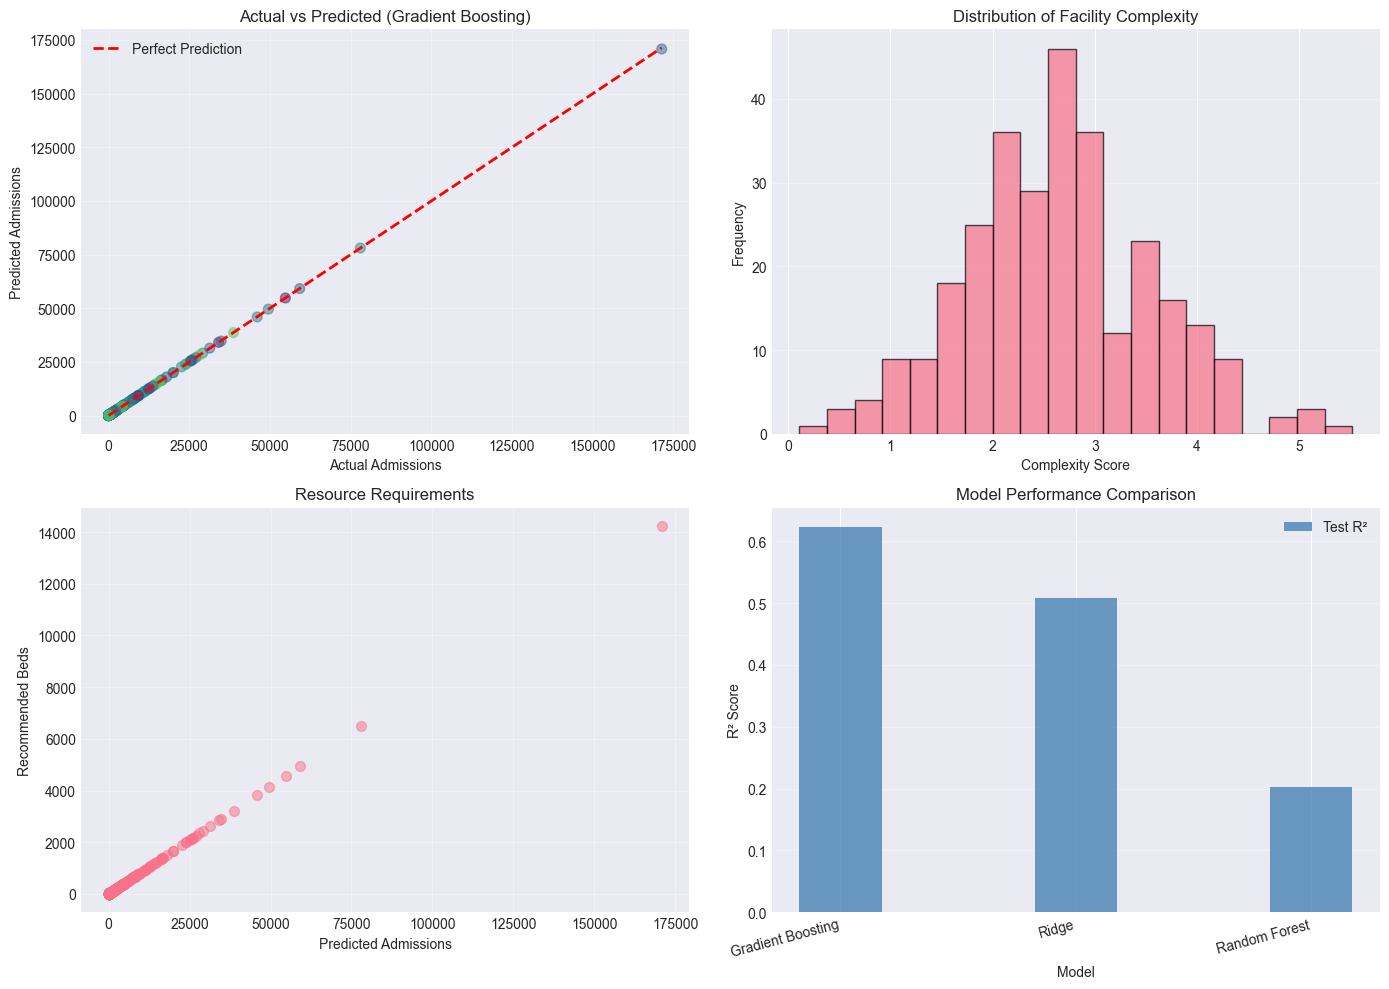

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
ax = axes[0, 0]
ax.scatter(
    df_grouped["total_admissions"],
    df_grouped["predicted_admissions"],
    alpha=0.5,
    s=50,
    c=df_grouped["complexity_score"],
    cmap="viridis",
)
ax.plot(
    [0, df_grouped["total_admissions"].max()],
    [0, df_grouped["total_admissions"].max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)
ax.set_xlabel("Actual Admissions")
ax.set_ylabel("Predicted Admissions")
ax.set_title(f"Actual vs Predicted ({best_model_info['Model']})")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Complexity Score Distribution
ax = axes[0, 1]
ax.hist(df_grouped["complexity_score"], bins=20, edgecolor="black", alpha=0.7)
ax.set_xlabel("Complexity Score")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Facility Complexity")
ax.grid(True, alpha=0.3, axis="y")

# Plot 3: Predicted vs Recommended Beds
ax = axes[1, 0]
ax.scatter(
    df_grouped["predicted_admissions"], df_grouped["recommended_beds"], alpha=0.5, s=50
)
ax.set_xlabel("Predicted Admissions")
ax.set_ylabel("Recommended Beds")
ax.set_title("Resource Requirements")
ax.grid(True, alpha=0.3)

# Plot 4: Model Performance Comparison
ax = axes[1, 1]
model_names = results_df["Model"].values
test_r2 = results_df["R2"].values
x = np.arange(len(model_names))
width = 0.35

ax.bar(x, test_r2, width, label="Test R²", alpha=0.8, color="steelblue")
ax.set_xlabel("Model")
ax.set_ylabel("R² Score")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=0, color="k", linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.show()